# 01. EDA — ESS 배터리 수명 예측

- 데이터: MIT-Stanford Battery Dataset (Severson et al., Nature Energy 2019)
- Batch1 = Train, Batch2 = Test, Batch3 = 추가 Test
- 타깃 Cycle Life = 방전용량이 정격 1.1Ah의 80%(0.88Ah)에 처음 도달한 사이클 수 (SOH 80%)

**구성**: 0 환경 → 1 데이터 구조·품질 점검(→ 셀 정리 규칙) → 2 EDA 질문 5개 → 3 요약(EDA → 모델 전략)

시행착오 기록은 `docs/learning-log.md` 참고

## 0. 환경 설정

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from sklearn.linear_model import LinearRegression

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))
from src.preprocess import PROC_DIR, BATCH_FILES, load_batch, extract_summary

plt.rcParams.update({'font.family': ['AppleGothic', 'Noto Sans CJK JP', 'sans-serif'], 'axes.unicode_minus': False})
pd.set_option('display.width', 200)
FIG_DIR = ROOT / 'results' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)
NOMINAL, EOL = 1.1, 0.88
BATCHES = ['b1', 'b2', 'b3']
BATCH_LABEL = {'b1': 'Batch1 (Train)', 'b2': 'Batch2 (Test)', 'b3': 'Batch3 (추가 Test)'}

## 1. 데이터 구조와 품질 점검

### 1.1 원본 로딩
- `.mat`이 MATLAB v7.3(HDF5) 형식이라 `mat73`으로 읽음 (`src/preprocess.py`)
- `ERROR:root: MATLAB type not supported: string` 로그는 barcode 같은 문자열 필드라 무시해도 됨

In [2]:
# 원본 summary (정리 전). 처음 1회는 .mat(배치당 2~3GB)을 읽어 수 분 걸리고, 이후엔 캐시를 읽음
raw = {}
for b in BATCHES:
    cache = PROC_DIR / f'batch{b[-1]}_summary.pkl'
    if not cache.exists():
        extract_summary(load_batch(b), b).to_pickle(cache)
    raw[b] = pd.read_pickle(cache)
    print(b, raw[b].shape, '셀', raw[b]['cell_id'].nunique())
raw['b1'].head()

b1 (38811, 11) 셀 46
b2 (26904, 11) 셀 47
b3 (51007, 11) 셀 46


,IR,QCharge,QDischarge,Tavg,Tmax,Tmin,chargetime,cycle,cell_id,policy,cycle_life
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,b1_c00,3.6C(80%)-3.6C,1190.0
1,0.016742,1.071042,1.070689,31.875011,35.652016,29.566130,13.341250,2.0,b1_c00,3.6C(80%)-3.6C,1190.0
2,0.016724,1.071674,1.071900,31.931490,35.692978,29.604385,13.425777,3.0,b1_c00,3.6C(80%)-3.6C,1190.0
3,0.016681,1.072304,1.072510,31.932603,35.680588,29.744202,13.425167,4.0,b1_c00,3.6C(80%)-3.6C,1190.0
4,0.016662,1.072970,1.073174,31.959322,35.728691,29.644709,13.341442,5.0,b1_c00,3.6C(80%)-3.6C,1190.0


### 1.2 컬럼 의미 (한 행 = 셀 1개의 사이클 1회)

| 컬럼 | 의미 | 단위 |
|---|---|---|
| IR | 내부저항, 열화되면 증가 | Ω |
| QCharge / QDischarge | 충전·방전 용량. QDischarge ÷ 1.1 = SOH | Ah |
| Tavg / Tmax / Tmin | 사이클 중 평균·최고·최저 온도 | °C |
| chargetime | 충전 소요 시간 | 분 |
| cycle | 사이클 번호 | 회 |
| policy | 충전 정책. `5.4C(40%)-3.6C` = SOC 40%까지 5.4C, 이후 3.6C | — |
| cycle_life | 타깃(수명). 셀마다 하나의 값이 모든 행에 반복 → 피처로 쓰면 안 됨 | 회 |

### 1.3 정답(수명)을 믿을 수 있는 셀인가?
- 정상 셀은 EOL(0.88Ah)에 닿은 직후 기록이 끝남 → 최소 용량이 0.880~0.883Ah
- 최소 용량이 이보다 확실히 높으면(0.89 초과) EOL 전에 기록이 끝난 것 → 기록된 수명은 실제 수명의 **하한값**
- 수명값이 비어 있는 셀은 VarCharge·SLOWCYCLE 같은 특수 실험

In [3]:
# 셀별 점검: 수명값 유무, 기록된 최소 방전용량 (0.5Ah 이하 측정 오류 제외)
rows = []
for b in BATCHES:
    d = raw[b][raw[b]['QDischarge'] > 0.5]
    info = d.groupby('cell_id').agg(cycle_life=('cycle_life', 'first'), policy=('policy', 'first'),
                                    last_cycle=('cycle', 'max'), min_QD=('QDischarge', 'min'))
    info['batch'] = b
    rows.append(info)
cells = pd.concat(rows)
cells['수명값 없음'] = cells['cycle_life'].isna()
cells['EOL 미도달'] = cells['min_QD'] > 0.89     # 정상 셀은 0.880~0.883에서 기록 종료 → 0.89 초과면 미도달

print(cells.groupby('batch')['min_QD'].describe()[['min', '25%', '50%', '75%', 'max']].round(4))
cells[cells['수명값 없음'] | cells['EOL 미도달']].sort_values(['batch', 'min_QD'], ascending=[True, False])

          min     25%     50%     75%     max
batch                                        
b1     0.8801  0.8804  0.8810  0.8832  1.0433
b2     0.8250  0.8258  0.8266  0.8277  1.0745
b3     0.8800  0.8802  0.8804  0.8806  0.9739


,cycle_life,policy,last_cycle,min_QD,batch,수명값 없음,EOL 미도달
cell_id,,,,,,,
b1_c02,1177.0,3.6C(80%)-3.6C,1176.0,1.043279,b1,False,True
b1_c01,1179.0,3.6C(80%)-3.6C,1178.0,1.038225,b1,False,True
b1_c04,1227.0,4C(80%)-4C,1226.0,1.021641,b1,False,True
b1_c00,1190.0,3.6C(80%)-3.6C,1189.0,1.008352,b1,False,True
b1_c03,1226.0,4C(80%)-4C,1225.0,0.970921,b1,False,True
b1_c08,879.0,5.4C(40%)-3.6C,878.0,0.969025,b1,False,True
b1_c22,891.0,6C(30%)-3.6C,890.0,0.963279,b1,False,True
b1_c10,906.0,5.4C(50%)-3C,905.0,0.961019,b1,False,True
b1_c13,897.0,5.4C(50%)-3.6C,896.0,0.923136,b1,False,True


**판단**
- Batch1: c00~c04(1,177~1,227에서 종료, 최소 0.97~1.04Ah), c08·c10·c12·c13·c22(879~906에서 종료) → 10셀 제거
  - c00~c04가 Batch2에서 이어 측정됐는지 확인 → Batch2의 같은 정책 셀은 초기 용량 1.07~1.09Ah로 새 셀 → 연장 데이터 없음
- Batch2: 수명값 없는 8셀(VarCharge 4, SLOWCYCLE 4) 제거 / Batch3: 수명값 없는 2셀 제거
- 시행착오: 처음엔 이상치 필터(QD > 0.88)와 EOL 기준이 같아서 "46셀 전부 미도달"로 잘못 나옴 → 필터 하한을 0.5로 변경

In [4]:
# 정리 결과 (src/preprocess.py 규칙 적용 후)
clean = {b: pd.read_pickle(PROC_DIR / f'{b}_summary_clean.pkl') for b in BATCHES}
pd.DataFrame({'원본': {b: raw[b]['cell_id'].nunique() for b in BATCHES},
              '정리 후': {b: clean[b]['cell_id'].nunique() for b in BATCHES}})

,원본,정리 후
b1,46,36
b2,47,39
b3,46,44


## 2. EDA 질문 5개 (정리된 데이터)
- 입력: `data/processed/` (`src/preprocess.py`, `src/features.py` 결과)
- **피처 선택·전략 결정은 Batch1(Train)만으로 한다.** Batch2·3 결과는 배치 간 차이를 보는 참고용

In [5]:
summ  = clean
qdlin = {b: pd.read_pickle(PROC_DIR / f'{b}_qdlin.pkl') for b in BATCHES}
feat  = pd.concat([pd.read_csv(PROC_DIR / f'features_{b}.csv', index_col=0) for b in BATCHES])

# 충전 정책 파싱: "5.4C(40%)-3.6C" → 1단계 C-rate 5.4, 전환 SOC 40%, 2단계 C-rate 3.6
pol = feat['policy'].str.extract(r'^([\d.]+)C\((\d+)%\)-([\d.]+)C')
feat['C1'], feat['switch_soc'], feat['C2'] = pol[0].astype(float), pol[1].astype(float), pol[2].astype(float)
feat['newstructure'] = feat['policy'].str.contains('newstructure')
feat.groupby('batch').size()

batch
b1    36
b2    39
b3    44
dtype: int64

## Q1. Cycle Life 분포는 어떻게 생겼는가?

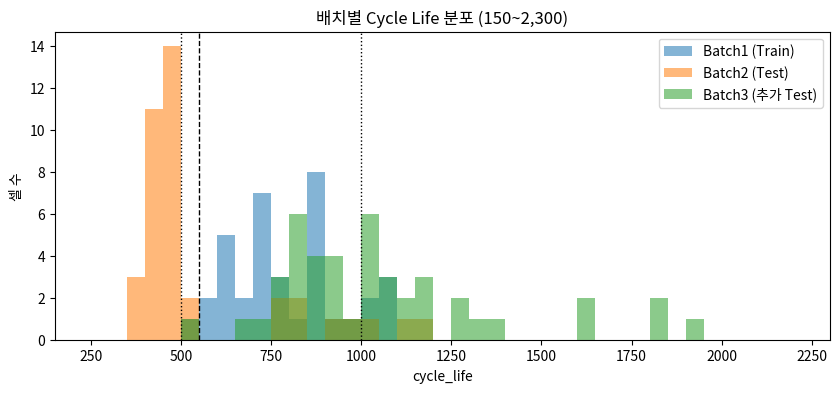

,n,min,median,max,long_gt1000,short_lt500,short_lt550
batch,,,,,,,
b1,36,534.0,772.5,1074.0,0.139,0.000,0.028
b2,39,392.0,472.0,1186.0,0.077,0.718,0.769
b3,44,541.0,1005.5,1935.0,0.523,0.000,0.023


In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
bins = np.arange(150, 2350, 50)
for b in BATCHES:
    ax.hist(feat.loc[feat['batch'] == b, 'cycle_life'], bins=bins, alpha=0.55, label=BATCH_LABEL[b])
for x, ls in [(500, ':'), (550, '--'), (1000, ':')]:
    ax.axvline(x, color='k', ls=ls, lw=1)
ax.set(title='배치별 Cycle Life 분포 (150~2,300)', xlabel='cycle_life', ylabel='셀 수', xlim=(150, 2300))
ax.legend()
fig.savefig(FIG_DIR / 'q1_cycle_life_hist.png', dpi=150, bbox_inches='tight')
plt.show()

ratio = feat.groupby('batch')['cycle_life'].agg(
    n='size', min='min', median='median', max='max',
    long_gt1000=lambda s: (s > 1000).mean(),
    short_lt500=lambda s: (s < 500).mean(),
    short_lt550=lambda s: (s < 550).mean())
ratio.round(3)

In [7]:
# 기술통계
st = feat.groupby('batch')['cycle_life'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
st['skew'] = feat.groupby('batch')['cycle_life'].apply(skew)
st['단수명(<500)'] = feat.groupby('batch')['cycle_life'].apply(lambda s: (s < 500).mean())
st['장수명(>1000)'] = feat.groupby('batch')['cycle_life'].apply(lambda s: (s > 1000).mean())
st['550 미만 셀'] = feat.groupby('batch')['cycle_life'].apply(lambda s: (s < 550).sum())
st.round(2)

,count,mean,std,min,median,max,skew,단수명(<500),장수명(>1000),550 미만 셀
batch,,,,,,,,,,
b1,36,788.42,148.70,534.0,772.5,1074.0,0.29,0.00,0.14,1
b2,39,565.74,222.20,392.0,472.0,1186.0,1.57,0.72,0.08,30
b3,44,1059.66,313.87,541.0,1005.5,1935.0,1.21,0.00,0.52,1


In [8]:
# 이상치 셀: 배치 안에서 log(수명) 기준 IQR 1.5배 밖 + 배치별 최단수명 3개
def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    return (s < q1 - 1.5 * (q3 - q1)) | (s > q3 + 1.5 * (q3 - q1))

feat['life_outlier'] = feat.groupby('batch')['log_cycle_life'].transform(iqr_outliers)
cols = ['batch', 'cycle_life', 'policy', 'C1', 'chargetime_mean_5', 'dQ_log_var']
print('IQR 이상치:')
display(feat[feat['life_outlier']][cols])
print('배치별 최단수명 3개:')
display(feat.sort_values('cycle_life').groupby('batch').head(3).sort_values(['batch', 'cycle_life'])[cols])
print('배치별 중앙값 (비교용):')
feat.groupby('batch')[['cycle_life', 'C1', 'chargetime_mean_5', 'dQ_log_var']].median().round(3)

IQR 이상치:


,batch,cycle_life,policy,C1,chargetime_mean_5,dQ_log_var
cell_id,,,,,,
b2_c07,b2,777.0,4.8C(80%)-4.8C-newstructure,4.8,10.036668,-4.436969
b2_c08,b2,904.0,5.2C(58%)-4C-newstructure,5.2,10.039683,-4.048784
b2_c09,b2,791.0,5.6C(26%)-4.5C-newstructure,5.6,10.040518,-4.074234
b2_c32,b2,809.0,4.8C(80%)-4.8C-newstructure,4.8,10.041733,-4.102907
b2_c33,b2,1140.0,5.2C(58%)-4C-newstructure,5.2,10.039380,-4.278158
b2_c34,b2,1186.0,5.6C(26%)-4.5C-newstructure,5.6,10.039870,-4.442689
b2_c43,b2,1029.0,4.8C(80%)-4.8C-newstructure,4.8,10.036313,-4.298838
b2_c44,b2,841.0,5.2C(58%)-4C-newstructure,5.2,10.040485,-4.373032
b2_c45,b2,997.0,5.6C(26%)-4.5C-newstructure,5.6,10.040134,-4.264289


배치별 최단수명 3개:


,batch,cycle_life,policy,C1,chargetime_mean_5,dQ_log_var
cell_id,,,,,,
b1_c20,b1,534.0,5.4C(80%)-5.4C,5.4,9.008858,-3.363507
b1_c21,b1,559.0,5.4C(80%)-5.4C,5.4,8.981738,-3.342297
b1_c45,b1,599.0,8C(35%)-3.6C,8.0,10.242064,-3.423197
b2_c19,b2,392.0,6C(60%)-3C,6.0,10.175164,-3.292164
b2_c06,b2,393.0,3.6C(9%)-5C,3.6,10.178854,-3.682411
b2_c15,b2,396.0,3.6C(9%)-5C,3.6,10.173891,-3.417112
b3_c28,b3,541.0,3.7C(31%)-5.9C-newstructure,3.7,10.060723,-3.441342
b3_c06,b3,667.0,3.7C(31%)-5.9C-newstructure,3.7,10.064076,-3.516391
b3_c31,b3,731.0,5.9C(60%)-3.1C-newstructure,5.9,10.046283,-3.823472


배치별 중앙값 (비교용):


,cycle_life,C1,chargetime_mean_5,dQ_log_var
batch,,,,
b1,772.5,6.0,10.785,-3.774
b2,472.0,5.2,10.174,-3.493
b3,1005.5,5.3,10.044,-4.152


**해석**
- 배치 간 분포가 크게 다름 (중앙값 Batch1 773 / Batch2 472 / Batch3 1,006). 단수명(<500) Batch2 72%, 장수명(>1,000) Batch3 52%
- Batch1에서 550 미만은 36셀 중 1셀 → 분류(550 기준)로는 단수명 클래스를 학습할 수 없음
- Batch1 최단수명 2셀(534·559)은 5.4C(80%) 급속충전, 초기 충전시간 9.0분(Batch1 최단)
- Batch2는 newstructure 셀(9개, 777~1,186)과 일반 셀(30개, 392~514)로 갈림

**시사점** → 회귀 선택, 오차를 비율로 다루기 위해 log(수명) 타깃, Train 범위 밖 예측이 필요하므로 선형 모델 후보 포함

## Q2. 열화 곡선 — 방전 용량이 어떻게 감소하는가?

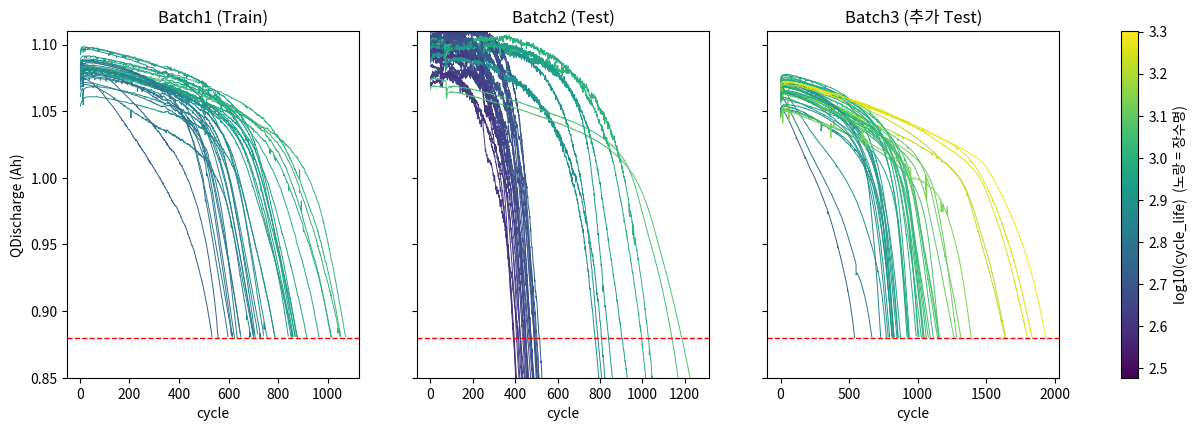

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
norm = plt.Normalize(np.log10(300), np.log10(2000))
for ax, b in zip(axes, BATCHES):
    for cid, g in summ[b].groupby('cell_id'):
        ax.plot(g['cycle'], g['QDischarge'], lw=0.7,
                color=plt.cm.viridis(norm(np.log10(g['cycle_life'].iloc[0]))))
    ax.axhline(EOL, color='r', ls='--', lw=1)
    ax.set(title=BATCH_LABEL[b], xlabel='cycle', ylim=(0.85, 1.11))
axes[0].set_ylabel('QDischarge (Ah)')
sm = plt.cm.ScalarMappable(norm=norm, cmap='viridis')
fig.colorbar(sm, ax=axes, label='log10(cycle_life)  (노랑 = 장수명)')
fig.savefig(FIG_DIR / 'q2_qd_curves_all.png', dpi=150, bbox_inches='tight')
plt.show()

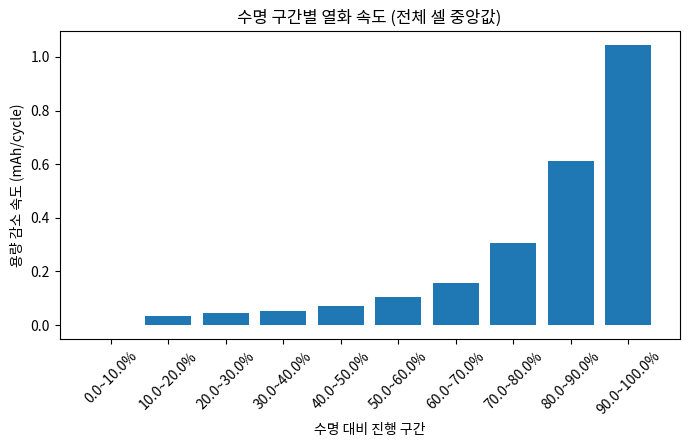

후반(90~100%) / 초반(10~20%) 감소 속도 비율 중앙값 (배치별):
batch
b1    25.0
b2   -17.1
b3    22.2
Name: ratio, dtype: float64


In [10]:
# 열화 속도: 수명을 10구간으로 나눠 구간별 용량 감소 속도(Ah/cycle) 비교
def rate_profile(g, n_bins=10):
    g = g.sort_values('cycle')
    life = g['cycle_life'].iloc[0]
    g = g.assign(frac=g['cycle'] / life)
    g['bin'] = pd.cut(g['frac'], np.linspace(0, 1, n_bins + 1), labels=False)
    out = {}
    for k, gg in g.groupby('bin'):
        if len(gg) >= 5:
            out[k] = -np.polyfit(gg['cycle'], gg['QDischarge'], 1)[0]   # 양수 = 감소 속도
    return pd.Series(out)

prof = pd.concat({cid: rate_profile(g) for b in BATCHES for cid, g in summ[b].groupby('cell_id')}, axis=1).T
prof.index.name = 'cell_id'
med = prof.median() * 1000
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([f'{i*10}~{i*10+10}%' for i in med.index], med.values)
ax.set(title='수명 구간별 열화 속도 (전체 셀 중앙값)', xlabel='수명 대비 진행 구간', ylabel='용량 감소 속도 (mAh/cycle)')
plt.xticks(rotation=45)
fig.savefig(FIG_DIR / 'q2_degradation_rate.png', dpi=150, bbox_inches='tight')
plt.show()
ratio = (prof[9] / prof[1]).rename('ratio').to_frame()
ratio['batch'] = ratio.index.str[:2]
print('후반(90~100%) / 초반(10~20%) 감소 속도 비율 중앙값 (배치별):')
print(ratio.groupby('batch')['ratio'].median().round(1))

knee / 수명 비율 중앙값 (배치별): {'b1': 0.75, 'b2': 0.78, 'b3': 0.79}
knee와 수명 상관: 0.994


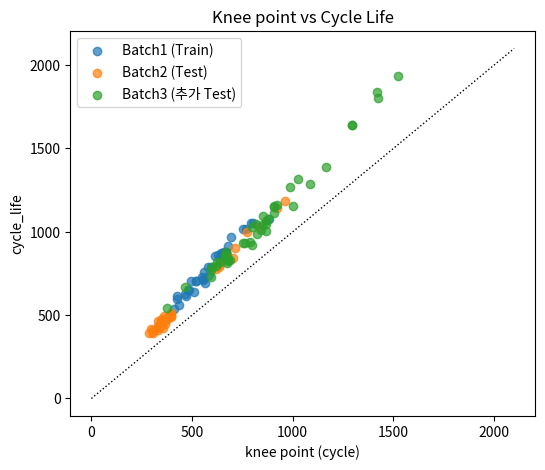

In [11]:
# Knee point: 두 직선으로 나눴을 때 오차가 가장 작은 분기점 (piecewise linear)
def knee_point(g, step=5):
    g = g.sort_values('cycle')
    x = g['cycle'].values
    y = g['QDischarge'].rolling(15, center=True, min_periods=1).median().values
    best, best_sse = np.nan, np.inf
    for k in range(20, len(x) - 20, step):
        sse = 0
        for xs, ys in [(x[:k], y[:k]), (x[k:], y[k:])]:
            coef = np.polyfit(xs, ys, 1)
            sse += ((np.polyval(coef, xs) - ys) ** 2).sum()
        if sse < best_sse:
            best, best_sse = x[k], sse
    return best

knee = pd.Series({cid: knee_point(g) for b in BATCHES for cid, g in summ[b].groupby('cell_id')}, name='knee')
feat['knee'] = knee
feat['knee_frac'] = feat['knee'] / feat['cycle_life']
print('knee / 수명 비율 중앙값 (배치별):', feat.groupby('batch')['knee_frac'].median().round(2).to_dict())
print('knee와 수명 상관:', feat[['knee', 'cycle_life']].corr().iloc[0, 1].round(3))

fig, ax = plt.subplots(figsize=(6, 5))
for b in BATCHES:
    d = feat[feat['batch'] == b]
    ax.scatter(d['knee'], d['cycle_life'], label=BATCH_LABEL[b], alpha=0.7)
lim = [0, 2100]
ax.plot(lim, lim, 'k:', lw=1)
ax.set(title='Knee point vs Cycle Life', xlabel='knee point (cycle)', ylabel='cycle_life')
ax.legend()
fig.savefig(FIG_DIR / 'q2_knee_vs_life.png', dpi=150, bbox_inches='tight')
plt.show()

**해석**
- 열화는 일정하지 않고 **가속**됨. Batch1 기준 수명 마지막 10% 구간 감소 속도가 10~20% 구간의 약 25배 (Batch3 약 22배. Batch2는 10~20% 구간에서 용량이 오히려 늘어 비율이 음수로 나와 해석에서 제외)
- Knee point는 Batch1 수명의 약 75% 지점, knee와 수명 상관 0.99
- 하지만 100사이클 시점엔 모든 셀이 1.06~1.10Ah에 겹쳐 있음 → knee를 직접 관측할 수 없음

**시사점** → 초기 용량 숫자로는 부족, knee 이전의 미세 신호(ΔQ)가 필요

## Q3. ΔQ(V) 곡선 — 초기 사이클에서 차이가 보이는가?
- ΔQ(V) = Q₁₀₀(V) − Q₁₀(V), 전압 축은 3.5V → 2.0V 1,000점 격자로 가정 (원 논문 기준)

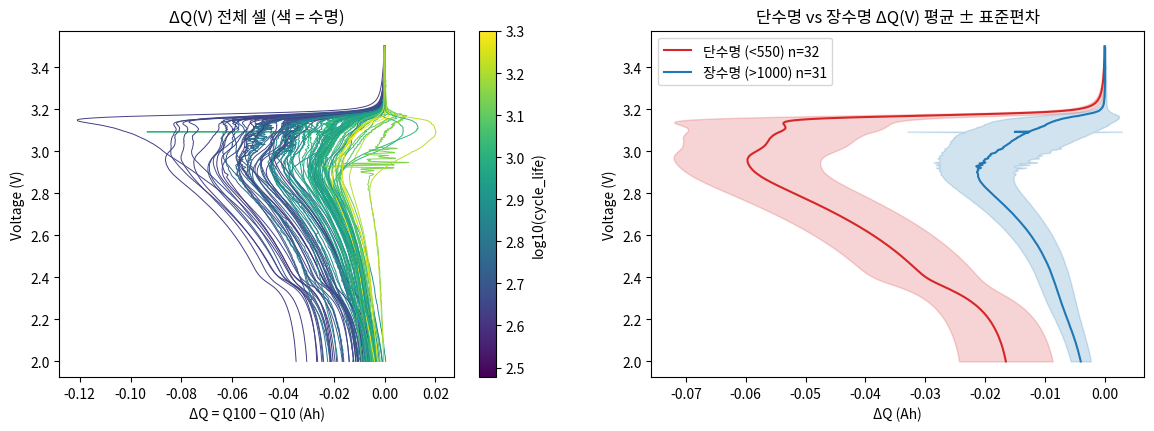

In [12]:
V = np.linspace(3.5, 2.0, 1000)
dq_curves = {cid: d[100] - d[10] for b in BATCHES for cid, d in qdlin[b].items()}

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for cid, dq in dq_curves.items():
    axes[0].plot(dq, V, lw=0.7, color=plt.cm.viridis(norm(feat.loc[cid, 'log_cycle_life'])))
axes[0].set(title='ΔQ(V) 전체 셀 (색 = 수명)', xlabel='ΔQ = Q100 − Q10 (Ah)', ylabel='Voltage (V)')
fig.colorbar(sm, ax=axes[0], label='log10(cycle_life)')

groups = {'단수명 (<550)': feat['cycle_life'] < 550, '장수명 (>1000)': feat['cycle_life'] > 1000}
for (name, mask), color in zip(groups.items(), ['tab:red', 'tab:blue']):
    arr = np.vstack([dq_curves[c] for c in feat.index[mask]])
    m, s = arr.mean(0), arr.std(0)
    axes[1].plot(m, V, color=color, label=f'{name} n={mask.sum()}')
    axes[1].fill_betweenx(V, m - s, m + s, color=color, alpha=0.2)
axes[1].set(title='단수명 vs 장수명 ΔQ(V) 평균 ± 표준편차', xlabel='ΔQ (Ah)', ylabel='Voltage (V)')
axes[1].legend()
fig.savefig(FIG_DIR / 'q3_delta_q_curves.png', dpi=150, bbox_inches='tight')
plt.show()

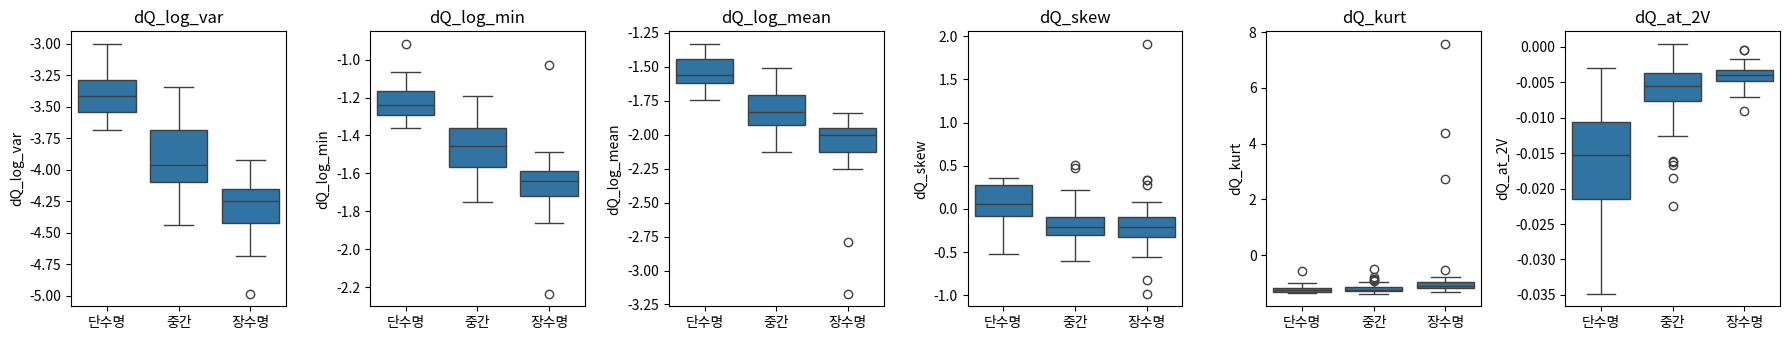

,dQ_log_var,dQ_log_min,dQ_log_mean,dQ_skew,dQ_kurt,dQ_at_2V
life_group,,,,,,
단수명,-3.415,-1.237,-1.559,0.051,-1.232,-0.015
장수명,-4.249,-1.637,-2.001,-0.214,-1.117,-0.004
중간,-3.966,-1.456,-1.835,-0.213,-1.240,-0.006


In [13]:
# 그룹별 ΔQ 통계 피처 분포
feat['life_group'] = np.select([feat['cycle_life'] < 550, feat['cycle_life'] > 1000], ['단수명', '장수명'], '중간')
dq_cols = ['dQ_log_var', 'dQ_log_min', 'dQ_log_mean', 'dQ_skew', 'dQ_kurt', 'dQ_at_2V']
fig, axes = plt.subplots(1, 6, figsize=(18, 3.5))
for ax, c in zip(axes, dq_cols):
    sns.boxplot(data=feat, x='life_group', y=c, order=['단수명', '중간', '장수명'], ax=ax)
    ax.set(title=c, xlabel='')
fig.tight_layout()
fig.savefig(FIG_DIR / 'q3_dq_features_by_group.png', dpi=150, bbox_inches='tight')
plt.show()
feat.groupby('life_group')[dq_cols].median().round(3)

**해석**
- 단수명 셀은 3.0V 부근에서 ΔQ가 크게 음수 (평균 −0.058 vs 장수명 −0.018Ah)
- `dQ_log_var` 중앙값 단수명 −3.42 / 장수명 −4.25로 뚜렷이 분리, 왜도·첨도는 차이 작음
- 일부 곡선에 수평으로 튀는 측정 노이즈 존재 (단수명/장수명 비교는 셀 수 확보를 위해 3개 배치 전체 사용)

**시사점** → ΔQ 통계량, 특히 분산(`dQ_log_var`)을 핵심 피처로

## Q4. 충전 조건(C-rate)과 수명의 관계는?

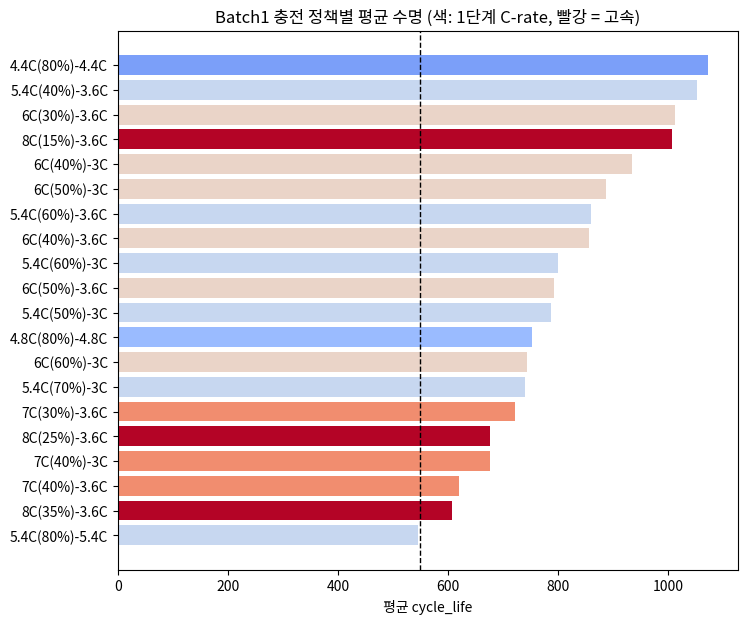

,n,life_mean,C1,chargetime,batches
policy,,,,,
5.4C(80%)-5.4C,2,546.5,5.4,9.0,b1
8C(35%)-3.6C,2,607.5,8.0,10.3,b1
7C(40%)-3.6C,2,621.0,7.0,10.3,b1
7C(40%)-3C,2,676.0,7.0,11.6,b1
8C(25%)-3.6C,2,676.5,8.0,11.2,b1
7C(30%)-3.6C,2,722.5,7.0,11.1,b1
5.4C(70%)-3C,2,739.5,5.4,9.9,b1
6C(60%)-3C,2,744.0,6.0,10.1,b1
4.8C(80%)-4.8C,2,753.0,4.8,10.1,b1


In [14]:
by_policy = (feat[feat['batch'] == 'b1'].groupby('policy')
             .agg(n=('cycle_life', 'size'), life_mean=('cycle_life', 'mean'), C1=('C1', 'first'),
                  chargetime=('chargetime_mean_5', 'mean'), batches=('batch', lambda s: ','.join(sorted(set(s)))))
             .sort_values('life_mean'))
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(by_policy.index, by_policy['life_mean'], color=plt.cm.coolwarm(plt.Normalize(3.5, 8)(by_policy['C1'])))
ax.axvline(550, color='k', ls='--', lw=1)
ax.set(title='Batch1 충전 정책별 평균 수명 (색: 1단계 C-rate, 빨강 = 고속)', xlabel='평균 cycle_life')
fig.savefig(FIG_DIR / 'q4_life_by_policy.png', dpi=150, bbox_inches='tight')
plt.show()
by_policy.round(1)

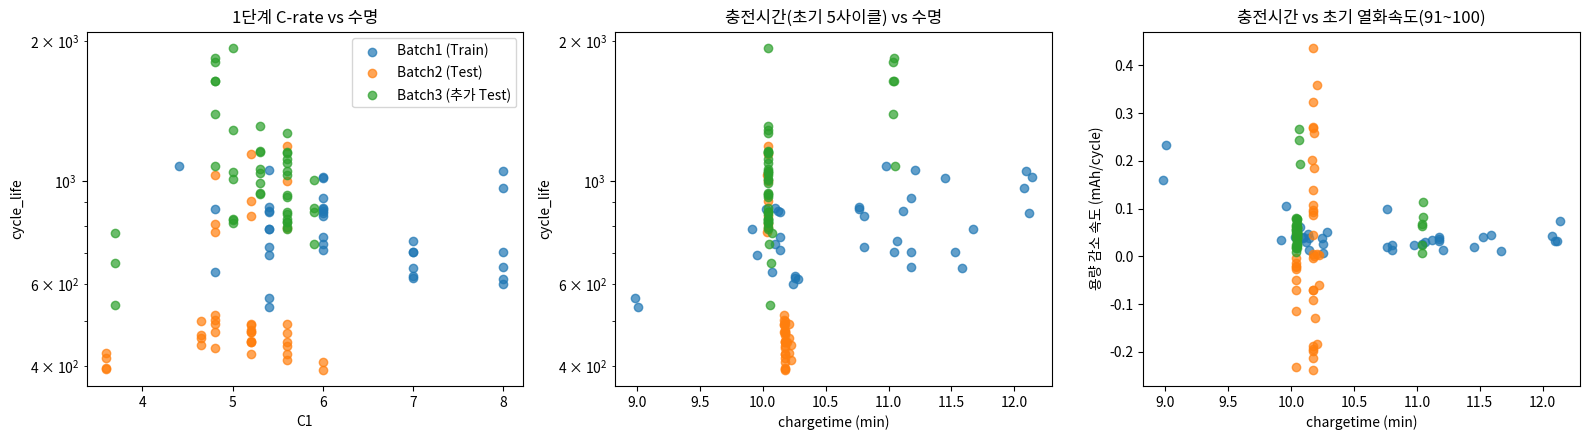

배치별 log 수명과의 상관 (Spearman):


,b1,b2,b3
C1,-0.24,0.06,-0.23
switch_soc,-0.06,0.29,0.44
C2,-0.16,-0.12,0.02
chargetime_mean_5,0.43,-0.79,0.24


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for b in BATCHES:
    d = feat[feat['batch'] == b]
    axes[0].scatter(d['C1'], d['cycle_life'], label=BATCH_LABEL[b], alpha=0.7)
    axes[1].scatter(d['chargetime_mean_5'], d['cycle_life'], alpha=0.7)
    axes[2].scatter(d['chargetime_mean_5'], -d['QD_slope_91_100'] * 1000, alpha=0.7)
axes[0].set(title='1단계 C-rate vs 수명', xlabel='C1', ylabel='cycle_life', yscale='log')
axes[1].set(title='충전시간(초기 5사이클) vs 수명', xlabel='chargetime (min)', ylabel='cycle_life', yscale='log')
axes[2].set(title='충전시간 vs 초기 열화속도(91~100)', xlabel='chargetime (min)', ylabel='용량 감소 속도 (mAh/cycle)')
axes[0].legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'q4_crate_vs_life.png', dpi=150, bbox_inches='tight')
plt.show()

cr = ['C1', 'switch_soc', 'C2', 'chargetime_mean_5']
print('배치별 log 수명과의 상관 (Spearman):')
pd.DataFrame({b: feat[feat['batch'] == b][cr + ['log_cycle_life']].corr('spearman')['log_cycle_life'][cr]
              for b in BATCHES}).round(2)

In [16]:
# 열화 속도(수명 전체 평균)와 충전 조건 상관
feat['avg_fade_rate'] = (feat.index.map(lambda c: prof.loc[c].mean()) * 1000)
t = feat[feat['batch'] == 'b1']
print('Batch1(Train) Spearman 상관')
pd.DataFrame({'log 수명': t[cr + ['log_cycle_life']].corr('spearman')['log_cycle_life'][cr],
              '평균 열화속도': t[cr + ['avg_fade_rate']].corr('spearman')['avg_fade_rate'][cr]}).round(2)

Batch1(Train) Spearman 상관


,log 수명,평균 열화속도
C1,-0.24,0.24
switch_soc,-0.06,0.10
C2,-0.16,0.24
chargetime_mean_5,0.43,-0.53


**해석**
- Batch1 정책 20개 평균 수명 547(5.4C(80%)) ~ 1,074(4.4C(80%))
- Batch1 기준 1단계 C-rate와 수명 상관은 약함(ρ = −0.24), 충전시간이 더 관련(ρ = +0.43), 충전시간이 짧을수록 열화가 빠름(ρ = −0.53)
- (참고) 충전시간 상관은 배치마다 부호가 바뀜 — Batch2는 충전시간이 거의 같아 의미 없음

**시사점** → C-rate보다 충전시간을 보조 피처로, 규제로 영향 제한

## Q5. 상관관계 — 어떤 신호가 수명과 연관되어 있는가?
- 선택 판단은 Batch1(Train) 열만 사용, 나머지 배치 열은 참고

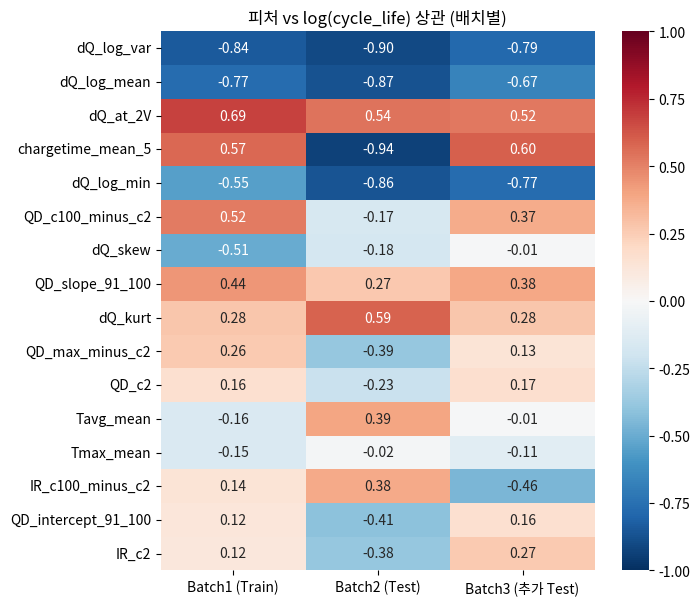

In [17]:
X_cols = ['QD_c2', 'QD_max_minus_c2', 'QD_c100_minus_c2', 'QD_slope_91_100', 'QD_intercept_91_100',
          'IR_c2', 'IR_c100_minus_c2', 'Tmax_mean', 'Tavg_mean', 'chargetime_mean_5',
          'dQ_log_var', 'dQ_log_min', 'dQ_log_mean', 'dQ_skew', 'dQ_kurt', 'dQ_at_2V']
corr_tbl = pd.DataFrame({BATCH_LABEL[b]: feat[feat['batch'] == b][X_cols + ['log_cycle_life']]
                         .corr()['log_cycle_life'][X_cols] for b in BATCHES})
corr_tbl = corr_tbl.reindex(corr_tbl.iloc[:, 0].abs().sort_values(ascending=False).index)
fig, ax = plt.subplots(figsize=(7, 7))
sns.heatmap(corr_tbl, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('피처 vs log(cycle_life) 상관 (배치별)')
fig.savefig(FIG_DIR / 'q5_corr_with_life.png', dpi=150, bbox_inches='tight')
plt.show()

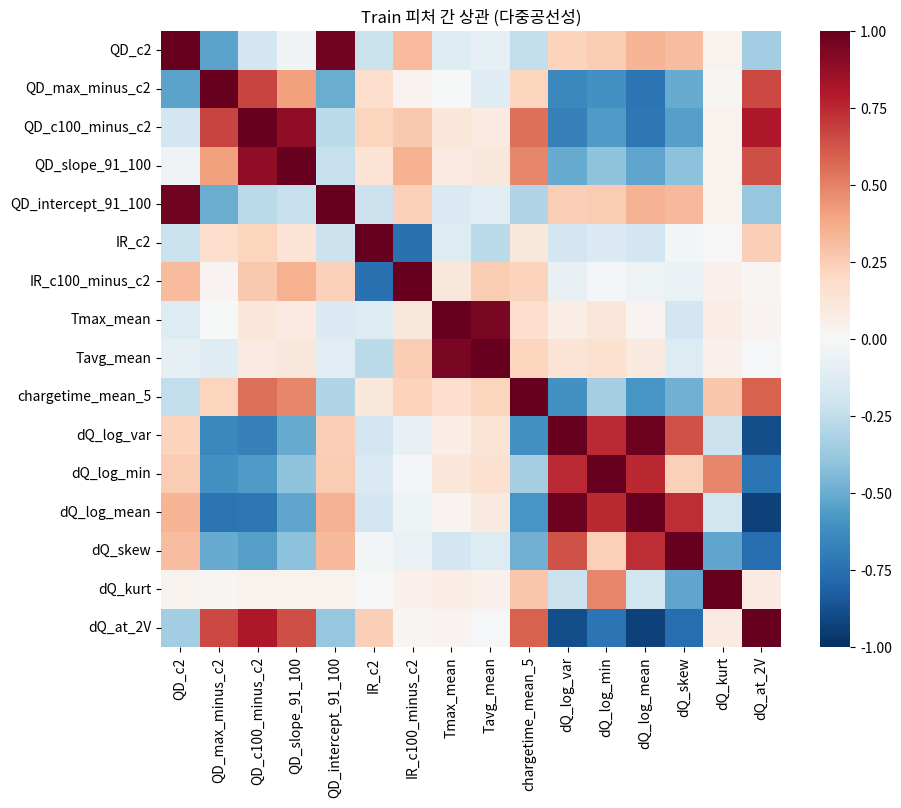

상관 |r| > 0.8 피처 쌍:


dQ_log_var        dQ_log_mean            0.98
QD_c2             QD_intercept_91_100    0.97
Tmax_mean         Tavg_mean              0.95
dQ_log_mean       dQ_at_2V               0.94
QD_c100_minus_c2  QD_slope_91_100        0.89
dQ_log_var        dQ_at_2V               0.88
QD_c100_minus_c2  dQ_at_2V               0.81
dtype: float64

VIF (10 이상이면 다중공선성 의심):


QD_c2                  19996.1
QD_intercept_91_100    19212.6
QD_slope_91_100         4688.8
QD_c100_minus_c2        2102.5
dQ_log_min              1207.4
dQ_log_mean             1048.7
dQ_log_var               823.7
dQ_kurt                  582.4
dQ_skew                   61.0
dQ_at_2V                  53.6
QD_max_minus_c2           46.9
Tavg_mean                 29.1
Tmax_mean                 25.3
IR_c100_minus_c2          10.2
IR_c2                      9.0
chargetime_mean_5          5.0
dtype: float64

In [18]:
# 다중공선성: 피처끼리 상관 + VIF (Train 기준)
Xtr = feat[feat['batch'] == 'b1'][X_cols]
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(Xtr.corr(), cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Train 피처 간 상관 (다중공선성)')
fig.savefig(FIG_DIR / 'q5_feature_corr.png', dpi=150, bbox_inches='tight')
plt.show()

def vif(X):
    X = (X - X.mean()) / X.std()
    out = {}
    for c in X.columns:
        others = X.drop(columns=c)
        r2 = LinearRegression().fit(others, X[c]).score(others, X[c])
        out[c] = 1 / (1 - r2) if r2 < 1 else np.inf
    return pd.Series(out).sort_values(ascending=False)

pairs = (Xtr.corr().abs().where(np.triu(np.ones((len(X_cols),) * 2), 1).astype(bool))
         .stack().sort_values(ascending=False))
print('상관 |r| > 0.8 피처 쌍:')
display(pairs[pairs > 0.8].round(2))
print('VIF (10 이상이면 다중공선성 의심):')
vif(Xtr).round(1)

**해석**
- 가장 강한 신호: `dQ_log_var` (Batch1 r = −0.84)
- 다중공선성 심각: dQ_log_var ↔ dQ_log_mean 0.98, dQ_log_var ↔ dQ_at_2V 0.88, Tmax ↔ Tavg 0.95, VIF 최대 수만
- 온도·내부저항은 |r| < 0.2로 약함

**시사점** → 중복 피처 제거 규칙(서로 |r| > 0.85면 하나만) + 규제 모델. 피처 선택은 `02_feature_engineering.ipynb`

## 3. 요약 — EDA 발견 → 모델 전략

| EDA 발견 | 전략 반영 |
|---|---|
| 수명 정답이 불확실한 셀 존재 (1.3) | 셀 제거 → 36 / 39 / 44셀 |
| Test가 Train 수명 범위 밖, Train 단수명 1셀 (Q1) | 회귀 + log 타깃, 범위 밖 예측 가능한 선형 모델 |
| 100사이클 용량으론 구별 불가, 열화 가속 (Q2) | 곡선 기반 피처 필요 |
| ΔQ에서 장·단수명 차이 뚜렷 (Q3) | ΔQ 통계량 핵심 피처 |
| C-rate 상관 약함, 충전시간은 열화와 연관 (Q4) | 충전시간 보조 피처 |
| 피처 간 상관 최대 0.98 (Q5) | 선택 규칙 + 규제 모델 |

→ 모델링 결과와 전략 수정 과정은 `03_modeling.ipynb`